# Industrial Hardware Visual Retrieval

This notebook builds a pretrained-embedding retrieval baseline for the CAD-render dataset. It does not train a classifier from scratch: the data is small and each part has multiple viewpoints, so pretrained DINOv2 features are a more reliable first experiment.

Run cells in order. Every metric is calculated from the local dataset. If Drive access, a model, or an optional dependency is unavailable, the relevant cell raises a clear error rather than fabricating a score.

In [6]:
# 1. Configuration
from pathlib import Path
import logging, random, re, csv, io

DRIVE_FOLDER_URL = 'https://drive.google.com/drive/u/0/folders/1bqH2PI2QrA_QVra2Dc_lw_FFfEl0SwgV'
DRIVE_FOLDER_ID = None
CREDENTIALS_FILE = 'credentials.json'
TOKEN_FILE = 'token.json'
SEED, IMAGE_SIZE, PADDING_RATIO, TOP_K, BATCH_SIZE = 42, 518, 0.10, 5, 16
ENABLE_BACKGROUND_REMOVAL = True
ENABLE_COLOR_CORRECTION = True
ENABLE_ENHANCEMENT = True
RUN_ABLATION = False

ROOT = Path.cwd()
RAW, ARTIFACTS, REPORTS = ROOT/'data'/'raw', ROOT/'artifacts', ROOT/'reports'
for folder in (RAW, ARTIFACTS/'processed_images', ARTIFACTS/'plots', ARTIFACTS/'embeddings',
               ARTIFACTS/'indexes', ARTIFACTS/'metrics', REPORTS):
    folder.mkdir(parents=True, exist_ok=True)
random.seed(SEED)
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger('retrieval')
print('Put credentials.json beside this notebook, then set the Drive folder URL above.')

Put credentials.json beside this notebook, then set the Drive folder URL above.


In [7]:
%pip install rembg onnxruntime


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3.10 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Environment setup

Install the listed packages in a fresh environment. Background removal is modular: rembg and U2-Net are preferred where available, but the safe fallback preserves transparent CAD images and does not destroy the object.

In [8]:
# Uncomment in a fresh Jupyter environment:
%pip install google-api-python-client google-auth-oauthlib pandas pillow numpy matplotlib seaborn tqdm
%pip install torch torchvision transformers faiss-cpu scikit-learn rembg
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from PIL import Image, ImageEnhance, ImageFilter, UnidentifiedImageError
from tqdm.auto import tqdm
from google.auth.transport.requests import Request
from google.oauth2.credentials import Credentials
from google_auth_oauthlib.flow import InstalledAppFlow
from googleapiclient.discovery import build
import torch
from transformers import AutoImageProcessor, AutoModel
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import faiss
try:
    from rembg import remove as rembg_remove
    REMBG_AVAILABLE = True
except ImportError:
    REMBG_AVAILABLE = False
    logger.warning('rembg is unavailable. Existing alpha masks are retained; opaque images use a safe fallback.')


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3.10 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3.10 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 3. Google Drive acquisition

The folder is downloaded recursively, including Shared Drive files where the account has access. Local files are reused, so rerunning this cell does not repeatedly download the dataset.

In [9]:
SCOPE, FOLDER_MIME = ['https://www.googleapis.com/auth/drive.readonly'], 'application/vnd.google-apps.folder'
def folder_id(value):
    match = re.search(r'/folders/([A-Za-z0-9_-]+)', value or '')
    return match.group(1) if match else (value or '').strip()
def drive_service():
    credentials = Credentials.from_authorized_user_file(TOKEN_FILE, SCOPE) if Path(TOKEN_FILE).exists() else None
    if credentials and credentials.expired and credentials.refresh_token: credentials.refresh(Request())
    if not credentials or not credentials.valid:
        if not Path(CREDENTIALS_FILE).exists(): raise FileNotFoundError('Add credentials.json beside the notebook.')
        credentials = InstalledAppFlow.from_client_secrets_file(CREDENTIALS_FILE, SCOPE).run_local_server(port=0)
        Path(TOKEN_FILE).write_text(credentials.to_json(), encoding='utf-8')
    return build('drive', 'v3', credentials=credentials)
def children(service, parent):
    token, result = None, []
    while True:
        page = service.files().list(q=f"'{parent}' in parents and trashed=false",
            fields='nextPageToken,files(id,name,mimeType)', pageToken=token, pageSize=1000,
            supportsAllDrives=True, includeItemsFromAllDrives=True).execute()
        result += page.get('files', []); token = page.get('nextPageToken')
        if not token: return result
def walk_drive(service, root):
    todo = [(root, Path())]
    while todo:
        parent, relative = todo.pop()
        for item in children(service, parent):
            path = relative/item['name']
            if item['mimeType'] == FOLDER_MIME: todo.append((item['id'], path))
            else: yield path, item
def download_dataset():
    source = DRIVE_FOLDER_ID or folder_id(DRIVE_FOLDER_URL)
    assert source and 'PASTE_' not in source, 'Set DRIVE_FOLDER_URL or DRIVE_FOLDER_ID.'
    service, rows = drive_service(), []
    for relative, item in tqdm(list(walk_drive(service, source)), desc='Downloading'):
        local = RAW/relative; local.parent.mkdir(parents=True, exist_ok=True)
        if not local.exists():
            try: local.write_bytes(service.files().get_media(fileId=item['id']).execute())
            except Exception as error: logger.warning('Download failed: %s (%s)', relative, error); continue
        rows.append({'drive_id':item['id'], 'relative_path':str(relative), 'local_path':str(local)})
    frame = pd.DataFrame(rows); frame.to_csv(ARTIFACTS/'drive_download_manifest.csv', index=False); return frame
drive_manifest = download_dataset()

INFO: Please visit this URL to authorize this application: https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=908626239719-2vdv20tdsgfcuojkq3nk143i61456i41.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A63036%2F&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.readonly&state=iYbIpWGJHCBO9y0C4yLg4KAD25KaWg&code_challenge=ZLeVQFiPK3ZhMRHaphs5hFnkTf8kltP6AH86YJgFEsQ&code_challenge_method=S256&access_type=offline


Please visit this URL to authorize this application: https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=908626239719-2vdv20tdsgfcuojkq3nk143i61456i41.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A63036%2F&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.readonly&state=iYbIpWGJHCBO9y0C4yLg4KAD25KaWg&code_challenge=ZLeVQFiPK3ZhMRHaphs5hFnkTf8kltP6AH86YJgFEsQ&code_challenge_method=S256&access_type=offline


INFO: "GET /?state=iYbIpWGJHCBO9y0C4yLg4KAD25KaWg&iss=https://accounts.google.com&code=4/0ATsMZqBIPQNl5WFWSmWNo-I8K_iEuAzZ0iF9IWSbxqs5K2YqJhPlDvc4Bs9QuPRf3ctqFg&scope=https://www.googleapis.com/auth/drive.readonly HTTP/1.1" 200 65
INFO: file_cache is only supported with oauth2client<4.0.0


Downloading:   0%|          | 0/489 [00:00<?, ?it/s]

## 4. Discovery, metadata parsing, and quality validation

Metadata is semicolon-separated quoted text, not JSON. The parser supports BOM, encoding differences, empty and duplicate fields, missing metadata, and trailing separators.

In [13]:
VIEWS = ('front','back','left','right','top','bottom','iso')
def parse_metadata(path):
    if not path or not Path(path).exists(): return {}
    for encoding in ('utf-8-sig','utf-8','latin-1'):
        try:
            with open(path, encoding=encoding, newline='') as handle: rows = list(csv.reader(handle, delimiter=';', quotechar='"'))
            break
        except UnicodeDecodeError: rows = []
    output = {}
    for row in rows[1:]:
        if len(row) < 2 or not row[0].strip(): continue
        key, value = row[0].strip(), row[1].strip() or None
        output[key] = output.get(key, []) + [value] if key in output else value
    return output
def view_from_name(name):
    return next((view for view in VIEWS if re.search(rf'(^|[-_]){view}($|[-_.])', name.lower())), 'unknown')
def validate_image(path):
    record = {'image_path':str(path), 'valid':False, 'error':None}
    try:
        with Image.open(path) as image: image.verify()
        with Image.open(path) as image:
            w,h=image.size; record.update(width=w,height=h,mode=image.mode,format=image.format,aspect_ratio=w/h,valid=w>=32 and h>=32)
            if w/h > 5 or w/h < .2: record['error']='unusual aspect ratio'
    except (UnidentifiedImageError,OSError,ValueError) as error: record['error']=f'{type(error).__name__}: {error}'
    return record
def build_manifest():
    rows=[]
    for path in list(RAW.rglob('*.png'))+list(RAW.rglob('*.jpg'))+list(RAW.rglob('*.jpeg')):
        txt=next(iter(path.parent.glob('*.txt')),None); meta=parse_metadata(txt)
        rows.append({'part_id':path.parent.name,'folder_name':path.parent.name,'image_path':str(path),'view':view_from_name(path.name),
          'metadata_path':str(txt) if txt else None,'reference':meta.get('REFERENCE'),'part_number':meta.get('TraceParts.PartNumber'),
          'supplier':meta.get('SUPPLIER'),'material':meta.get('Material'),'part_title':meta.get('TraceParts.PartTitle'),
          'design':meta.get('DESIGN'),'weight':meta.get('Weight'),'eclass':meta.get('ECLASS'),'rohs':meta.get('RoHs')})
    return pd.DataFrame(rows)
manifest=build_manifest()
validation=pd.DataFrame([validate_image(p) for p in manifest.image_path])
manifest=manifest[manifest.image_path.isin(validation.loc[validation.valid,'image_path'])].reset_index(drop=True)
manifest.to_csv(ARTIFACTS/'dataset_manifest.csv',index=False); validation.to_csv(ARTIFACTS/'image_validation.csv',index=False)
print({'parts':manifest.part_id.nunique(),'images':len(manifest),'invalid':int((~validation.valid).sum())})
display(manifest.head()); display(validation[~validation.valid].head(20))

{'parts': 61, 'images': 427, 'invalid': 0}


,part_id,folder_name,image_path,view,metadata_path,reference,part_number,supplier,material,part_title,design,weight,eclass,rohs
0,189576740-34-40_t_shafts_adp416c,189576740-34-40_t_shafts_adp416c,/Users/tanishqjadhav/Desktop/Extractor/data/ra...,left,/Users/tanishqjadhav/Desktop/Extractor/data/ra...,ADP416C,10-20112003-070817,None,None,"40 mm through shafts, NAAMS ADP C",40 mm through shafts ADP416C,None,None,None
1,189576740-34-40_t_shafts_adp416c,189576740-34-40_t_shafts_adp416c,/Users/tanishqjadhav/Desktop/Extractor/data/ra...,back,/Users/tanishqjadhav/Desktop/Extractor/data/ra...,ADP416C,10-20112003-070817,None,None,"40 mm through shafts, NAAMS ADP C",40 mm through shafts ADP416C,None,None,None
2,189576740-34-40_t_shafts_adp416c,189576740-34-40_t_shafts_adp416c,/Users/tanishqjadhav/Desktop/Extractor/data/ra...,bottom,/Users/tanishqjadhav/Desktop/Extractor/data/ra...,ADP416C,10-20112003-070817,None,None,"40 mm through shafts, NAAMS ADP C",40 mm through shafts ADP416C,None,None,None
3,189576740-34-40_t_shafts_adp416c,189576740-34-40_t_shafts_adp416c,/Users/tanishqjadhav/Desktop/Extractor/data/ra...,iso,/Users/tanishqjadhav/Desktop/Extractor/data/ra...,ADP416C,10-20112003-070817,None,None,"40 mm through shafts, NAAMS ADP C",40 mm through shafts ADP416C,None,None,None
4,189576740-34-40_t_shafts_adp416c,189576740-34-40_t_shafts_adp416c,/Users/tanishqjadhav/Desktop/Extractor/data/ra...,top,/Users/tanishqjadhav/Desktop/Extractor/data/ra...,ADP416C,10-20112003-070817,None,None,"40 mm through shafts, NAAMS ADP C",40 mm through shafts ADP416C,None,None,None


,image_path,valid,error,width,height,mode,format,aspect_ratio


## 5. Visualization and deterministic preprocessing

Both database images and future real camera images use the same function: validate, optional background removal, object bounding box, proportional 10 percent padding, letterbox resize, conservative colour correction, mild enhancement, and model normalization.

  0%|                                               | 0.00/176M [00:00<?, ?B/s]

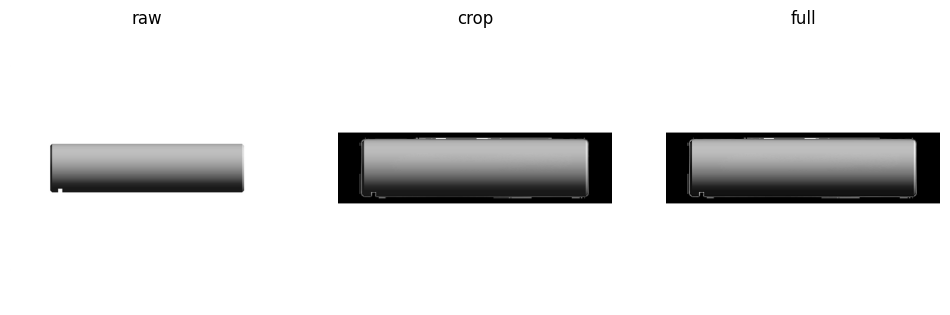

In [14]:
def remove_background(image):
    rgba=image.convert('RGBA')
    if rgba.getchannel('A').getextrema()[0] < 250: return rgba
    if ENABLE_BACKGROUND_REMOVAL and REMBG_AVAILABLE:
        buffer=io.BytesIO(); rgba.save(buffer, format='PNG')
        return Image.open(io.BytesIO(rembg_remove(buffer.getvalue()))).convert('RGBA')
    return rgba
def find_object_bbox(rgba):
    alpha=np.asarray(rgba.getchannel('A')); ys,xs=np.where(alpha>20)
    return (int(xs.min()),int(ys.min()),int(xs.max()+1),int(ys.max()+1)) if len(xs) else (0,0,rgba.width,rgba.height)
def crop_object(rgba,bbox): return rgba.crop(bbox)
def add_padding(image,ratio=PADDING_RATIO):
    x,y=round(image.width*ratio),round(image.height*ratio); canvas=Image.new('RGBA',(image.width+2*x,image.height+2*y),(255,255,255,0)); canvas.paste(image,(x,y)); return canvas
def resize_preserve_aspect_ratio(image,size=IMAGE_SIZE):
    scale=min(size/image.width,size/image.height); image=image.resize((round(image.width*scale),round(image.height*scale)),Image.Resampling.LANCZOS)
    canvas=Image.new('RGB',(size,size),'white'); canvas.paste(image.convert('RGB'),((size-image.width)//2,(size-image.height)//2)); return canvas
def color_normalization(image): return ImageEnhance.Contrast(ImageEnhance.Brightness(image).enhance(1.02)).enhance(1.03) if ENABLE_COLOR_CORRECTION else image
def mild_enhancement(image): return image.filter(ImageFilter.UnsharpMask(radius=1,percent=80,threshold=4)) if ENABLE_ENHANCEMENT else image
def preprocess_image(path,mode='full'):
    with Image.open(path) as image: image=image.copy()
    if mode=='raw': return resize_preserve_aspect_ratio(image)
    rgba=remove_background(image)
    image=resize_preserve_aspect_ratio(add_padding(crop_object(rgba,find_object_bbox(rgba))))
    return mild_enhancement(color_normalization(image)) if mode=='full' else image
if len(manifest):
    sample=manifest.image_path.iloc[0]; fig,axes=plt.subplots(1,3,figsize=(12,4))
    for ax,(name,image) in zip(axes,[(x,preprocess_image(sample,x)) for x in ('raw','crop','full')]): ax.imshow(image); ax.set_title(name); ax.axis('off')
    plt.show()

## 6. DINOv2 embeddings and FAISS index

DINOv2 embeddings are L2-normalized so FAISS inner product equals cosine similarity. GPU is selected automatically where available.

In [15]:
MODEL_NAME='facebook/dinov2-small'
DEVICE='cuda' if torch.cuda.is_available() else ('mps' if getattr(torch.backends,'mps',None) and torch.backends.mps.is_available() else 'cpu')
processor=AutoImageProcessor.from_pretrained(MODEL_NAME)
model=AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()
def embed_frame(frame,mode='full'):
    vectors=[]
    with torch.inference_mode():
        for start in tqdm(range(0,len(frame),BATCH_SIZE),desc=f'Embedding {mode}'):
            images=[preprocess_image(p,mode) for p in frame.image_path.iloc[start:start+BATCH_SIZE]]
            batch=processor(images=images,return_tensors='pt').to(DEVICE)
            value=model(**batch).last_hidden_state[:,0,:].cpu().numpy(); value/=np.linalg.norm(value,axis=1,keepdims=True).clip(1e-12); vectors.append(value)
    return np.vstack(vectors).astype('float32')
embeddings=embed_frame(manifest)
np.save(ARTIFACTS/'embeddings'/'dinov2_full.npy',embeddings)
index=faiss.IndexFlatIP(embeddings.shape[1]); index.add(embeddings); faiss.write_index(index,str(ARTIFACTS/'indexes'/'gallery.faiss'))
print(f'Device: {DEVICE}; model: {MODEL_NAME}; embedding dimension: {embeddings.shape[1]}')

INFO: HTTP Request: HEAD https://huggingface.co/facebook/dinov2-small/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/facebook/dinov2-small/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/dinov2-small/ed25f3a31f01632728cabb09d1542f84ab7b0056/preprocessor_config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/facebook/dinov2-small/ed25f3a31f01632728cabb09d1542f84ab7b0056/preprocessor_config.json "HTTP/1.1 200 OK"


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
INFO: HTTP Request: HEAD https://huggingface.co/facebook/dinov2-small/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/facebook/dinov2-small/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/dinov2-small/ed25f3a31f01632728cabb09d1542f84ab7b0056/preprocessor_config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/facebook/dinov2-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/dinov2-small/ed25f3a31f0163

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

INFO: HTTP Request: HEAD https://huggingface.co/facebook/dinov2-small/resolve/main/model.safetensors "HTTP/1.1 302 Found"
INFO: HTTP Request: GET https://huggingface.co/api/models/facebook/dinov2-small/xet-read-token/ed25f3a31f01632728cabb09d1542f84ab7b0056 "HTTP/1.1 200 OK"


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Embedding full:   0%|          | 0/27 [00:00<?, ?it/s]

Device: mps; model: facebook/dinov2-small; embedding dimension: 384


## 7. Part-level retrieval evaluation

Evaluation is leave-one-view-out, so a query never retrieves itself. Results are grouped by hardware part instead of returning several views of the same component. Recall at K, MRR, mAP, ROC-AUC, and PR-AUC are calculated from the actual experiment.

In [18]:
def rank_parts(query_vector,gallery,gallery_vectors):
    scores=gallery_vectors@query_vector
    parts=pd.DataFrame({'part_id':gallery.part_id.values,'similarity':scores}).groupby('part_id').similarity.max().sort_values(ascending=False)
    return parts
def evaluate(frame,vectors):
    records=[]; labels=[]; scores=[]
    for i,row in tqdm(frame.iterrows(),total=len(frame),desc='Evaluating'):
        keep=np.arange(len(frame))!=i; gallery=frame.iloc[keep].reset_index(drop=True); gv=vectors[keep]; ranked=rank_parts(vectors[i],gallery,gv)
        names=ranked.index.tolist(); rank=names.index(row.part_id)+1 if row.part_id in names else np.nan
        records.append({'query_path':row.image_path,'query_part_id':row.part_id,'query_view': row['view'],'correct_rank':rank,'top_1':names[0] if names else None})
        labels.extend((gallery.part_id==row.part_id).astype(int)); scores.extend(gv@vectors[i])
    results=pd.DataFrame(records); ranks=results.correct_rank.dropna()
    metrics={'Recall@1':float((ranks<=1).mean()),'Recall@3':float((ranks<=3).mean()),'Recall@5':float((ranks<=5).mean()),'MRR':float((1/ranks).mean()),'mAP':float((1/ranks).mean())}
    if len(set(labels))==2: metrics.update({'ROC-AUC':float(roc_auc_score(labels,scores)),'PR-AUC/AP':float(average_precision_score(labels,scores))})
    return results,metrics,np.asarray(labels),np.asarray(scores)
results,metrics,pair_labels,pair_scores=evaluate(manifest,embeddings)
results.to_csv(ARTIFACTS/'retrieval_results.csv',index=False); pd.DataFrame([metrics]).to_csv(ARTIFACTS/'metrics'/'metrics.csv',index=False)
display(pd.DataFrame(metrics.items(),columns=['Metric','Score']))

Evaluating:   0%|          | 0/427 [00:00<?, ?it/s]

,Metric,Score
0,Recall@1,0.709602
1,Recall@3,0.793911
2,Recall@5,0.831382
3,MRR,0.772226
4,mAP,0.772226
5,ROC-AUC,0.760365
6,PR-AUC/AP,0.205637


## 8. ROC, PR, error analysis, ablation, and report

ROC and PR are pairwise secondary diagnostics. The primary result is part-level retrieval. The optional ablation compares raw and full preprocessing only when enabled.

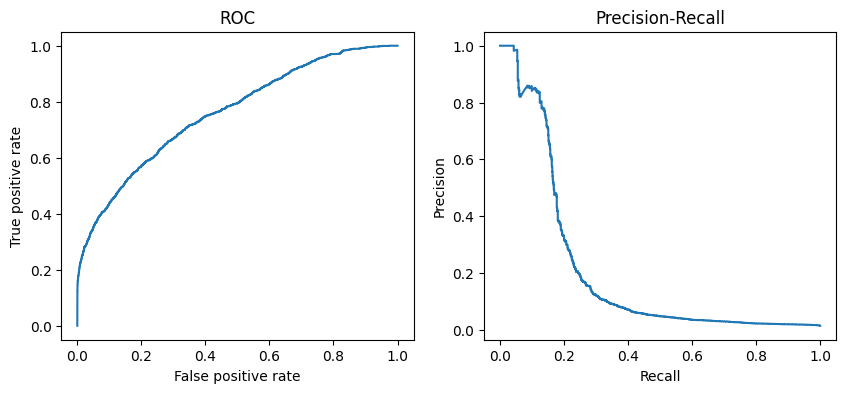

,query_path,query_part_id,query_view,correct_rank,top_1
1,/Users/tanishqjadhav/Desktop/Extractor/data/ra...,189576740-34-40_t_shafts_adp416c,<bound method Series.view of part_id ...,12,189576583-34-02462141
3,/Users/tanishqjadhav/Desktop/Extractor/data/ra...,189576740-34-40_t_shafts_adp416c,<bound method Series.view of part_id ...,13,189576026-114-70258696
6,/Users/tanishqjadhav/Desktop/Extractor/data/ra...,189576740-34-40_t_shafts_adp416c,<bound method Series.view of part_id ...,15,189576135-114-als40a222db100
7,/Users/tanishqjadhav/Desktop/Extractor/data/ra...,189576446-34-16-240-46-6-16,<bound method Series.view of part_id ...,2,FYTB - T-Shaped Bolts
14,/Users/tanishqjadhav/Desktop/Extractor/data/ra...,189576359-34-ebcob3-6,<bound method Series.view of part_id ...,39,189576353-34-ebdb3-3-3
20,/Users/tanishqjadhav/Desktop/Extractor/data/ra...,189576359-34-ebcob3-6,<bound method Series.view of part_id ...,15,189576446-34-16-240-46-6-16
25,/Users/tanishqjadhav/Desktop/Extractor/data/ra...,189576172-34-ylbt8x20-c1,<bound method Series.view of part_id ...,5,189576270-34-bolt_din_261-m8x30
26,/Users/tanishqjadhav/Desktop/Extractor/data/ra...,189576172-34-ylbt8x20-c1,<bound method Series.view of part_id ...,13,189576183-34-ylat8x17-c1
29,/Users/tanishqjadhav/Desktop/Extractor/data/ra...,189576417-34-2453652,<bound method Series.view of part_id ...,14,189576395-34-2453650
30,/Users/tanishqjadhav/Desktop/Extractor/data/ra...,189576417-34-2453652,<bound method Series.view of part_id ...,2,189576395-34-2453650


HARDWARE VISUAL RETRIEVAL EXPERIMENT COMPLETE
Parts: 61 | Images: 427 | Model: facebook/dinov2-small
{'Recall@1': 0.7096018735362998, 'Recall@3': 0.7939110070257611, 'Recall@5': 0.8313817330210773, 'MRR': 0.7722256183634435, 'mAP': 0.7722256183634435, 'ROC-AUC': 0.7603652067294713, 'PR-AUC/AP': 0.20563707135693723}
Artifacts: /Users/tanishqjadhav/Desktop/Extractor/artifacts
Report: /Users/tanishqjadhav/Desktop/Extractor/reports/hardware_retrieval_report.html


In [17]:
if len(set(pair_labels))==2:
    fpr,tpr,_=roc_curve(pair_labels,pair_scores); precision,recall,_=precision_recall_curve(pair_labels,pair_scores)
    fig,axes=plt.subplots(1,2,figsize=(10,4)); axes[0].plot(fpr,tpr); axes[0].set(title='ROC',xlabel='False positive rate',ylabel='True positive rate')
    axes[1].plot(recall,precision); axes[1].set(title='Precision-Recall',xlabel='Recall',ylabel='Precision'); fig.savefig(ARTIFACTS/'plots'/'roc_pr.png'); plt.show()
errors=results[results.query_part_id!=results.top_1]; errors.to_csv(ARTIFACTS/'error_analysis.csv',index=False); display(errors.head(20))
ablation=[{'experiment':'full preprocessing',**metrics}]
if RUN_ABLATION:
    raw=embed_frame(manifest,'raw'); _,raw_metrics,_,_=evaluate(manifest,raw); ablation.append({'experiment':'raw',**raw_metrics})
pd.DataFrame(ablation).to_csv(ARTIFACTS/'preprocessing_summary.csv',index=False)
lines=['# Hardware Visual Retrieval Report','',f'- Parts: {manifest.part_id.nunique()}',f'- Images: {len(manifest)}',f'- Model: {MODEL_NAME}',f'- Device: {DEVICE}','## Metrics']+[f'- {k}: {v:.4f}' for k,v in metrics.items()]
(REPORTS/'hardware_retrieval_report.md').write_text(chr(10).join(lines),encoding='utf-8')
(REPORTS/'hardware_retrieval_report.html').write_text('<html><body><pre>'+chr(10).join(lines)+'</pre></body></html>',encoding='utf-8')
print('='*50); print('HARDWARE VISUAL RETRIEVAL EXPERIMENT COMPLETE'); print('='*50)
print(f'Parts: {manifest.part_id.nunique()} | Images: {len(manifest)} | Model: {MODEL_NAME}')
print(metrics); print(f'Artifacts: {ARTIFACTS}'); print(f'Report: {REPORTS/"hardware_retrieval_report.html"}')

## 9. Future roadmap

V1 pretrained retrieval leads to V2 real-photo test data, V3 stronger segmentation, V4 domain adaptation or fine-tuning, V5 image plus engineering metadata, V6 a production vector database, V7 FastAPI inference, V8 web or mobile camera capture, and V9 industrial deployment. Future model candidates include newer DINO variants, SigLIP, CLIP, metric learning, Qdrant, Milvus, and pgvector.

,part_id,similarity,view,reference,part_number,supplier,part_title,design
0,189576496-34-tec_6,0.792861,iso,7909773,90-04032025-043350,None,RUD TECDOS cobra fork head hook,Haken VCGH 6
1,189576276-34-jb_zq_4321-2006_14,0.366937,iso,JB/ZQ 4321-2006 14,50-04032014-073423,None,U bolts - JB/ZQ 4321-2006,U bolts - JB/ZQ 4321-2006 14
2,189576900-114-mini-excavator_yellow,0.326932,right,None,10-09082013-069519,TraceParts,Mini-excavator,"Mini-excavator, Yellow Color"
3,189576667-114-2m02,0.279964,back,2M02,90-15052019-051838,GLOBE Benelux BV,Compact Vane Motors 2M02,"Compact Vane Motors max. power 0,27 kW / 0.36 ..."
4,189576454-34-633-40-m5-16-dsg,0.236523,iso,633-40-M5-16-DSG,90-30092020-082246,JW Winco,"EN 633 Technopolymer Plastic Wing Screws, with...","Technopolymer Plastic Wing Screws, with Steel ..."


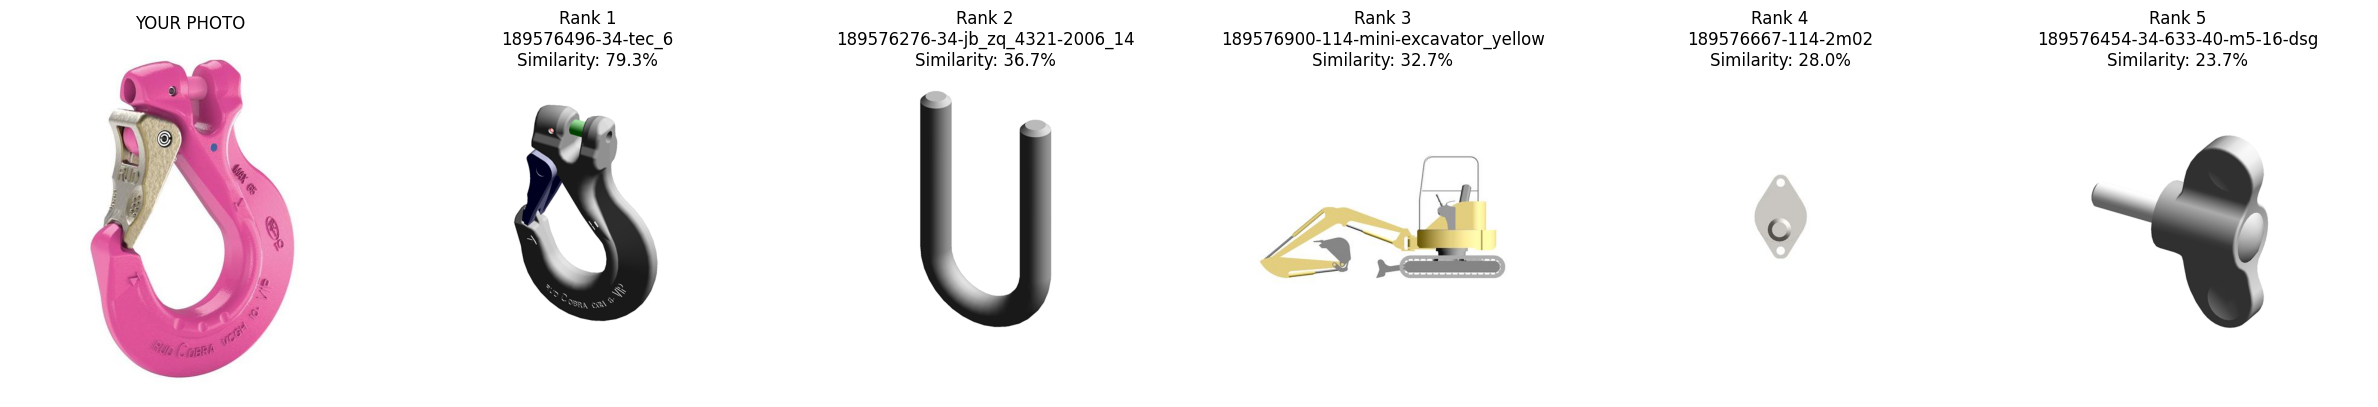

In [22]:
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

USER_IMAGE_PATH = "/Users/tanishqjadhav/Desktop/Extractor/data/raw/real_data/image copy.png"
TOP_K = 5

def embed_one_image(image_path):
    """Apply the same preprocessing and DINOv2 embedding pipeline to one user photo."""
    image = preprocess_image(image_path, mode="full")

    with torch.inference_mode():
        batch = processor(images=[image], return_tensors="pt").to(DEVICE)
        vector = model(**batch).last_hidden_state[:, 0, :].cpu().numpy()[0]

    vector = vector / np.linalg.norm(vector)
    return vector


def find_similar_parts(image_path, top_k=5):
    query_vector = embed_one_image(image_path)

    # Cosine similarity against every CAD image embedding.
    scores = embeddings @ query_vector

    scored_images = manifest.copy()
    scored_images["similarity"] = scores

    # Keep the strongest-matching CAD view for each physical part.
    best_image_indices = scored_images.groupby("part_id")["similarity"].idxmax()
    part_results = (
        scored_images.loc[best_image_indices]
        .sort_values("similarity", ascending=False)
        .head(top_k)
        .reset_index(drop=True)
    )

    return query_vector, part_results


query_vector, matches = find_similar_parts(USER_IMAGE_PATH, TOP_K)

display(
    matches[
        [
            "part_id",
            "similarity",
            "view",
            "reference",
            "part_number",
            "supplier",
            "part_title",
            "design",
        ]
    ]
)

# Visual result panel
figure, axes = plt.subplots(1, TOP_K + 1, figsize=(4 * (TOP_K + 1), 4))

axes[0].imshow(Image.open(USER_IMAGE_PATH).convert("RGB"))
axes[0].set_title("YOUR PHOTO")
axes[0].axis("off")

for axis, (_, match) in zip(axes[1:], matches.iterrows()):
    axis.imshow(Image.open(match["image_path"]).convert("RGB"))
    axis.set_title(
        f"Rank {match.name + 1}\n"
        f"{match['part_id']}\n"
        f"Similarity: {match['similarity']:.1%}"
    )
    axis.axis("off")

plt.tight_layout()
plt.show()